# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
df = pd.read_csv('https://cdn.kelasai.id/dataset_kelayakan_beasiswa.csv')
print("Data berhasil di-load!")
display(df.head())

Data berhasil di-load!


,IPK,Semester,Jurusan,Pernah_Mengulang,Pendapatan_Orang_Tua,Pekerjaan_Orang_Tua,Jumlah_Tanggungan,Status_Tempat_Tinggal,Asal_Daerah,Aktif_Organisasi,...,Skor_Motivasi_Tertulis,Surat_Rekomendasi,Pernah_Mendapat_Beasiswa,Skor_Keaktifan_Kampus,Rekam_Ketidakhadiran,Pernah_Melawan_Hukum,Jenis_Kelamin,Skor_Literasi_Finansial,Status_Kelayakan,Jumlah_Beasiswa_Per_Semester
0,3.40,2,Teknik Informatika,Tidak,4608603,Pedagang,2,Menumpang,3T,Tidak,...,77,Ada,Ya,55,6,Tidak,Laki-laki,71,Layak,3667971
1,3.14,7,Kedokteran,Tidak,5167265,Tidak Bekerja,1,Milik Sendiri,Perkotaan,Ya,...,98,Tidak,Ya,55,12,Tidak,Perempuan,77,Tidak Layak,0
2,3.83,5,Teknik Informatika,Tidak,9496414,Petani,4,Milik Sendiri,Pedesaan,Tidak,...,73,Ada,Ya,52,7,Tidak,Laki-laki,29,Tidak Layak,0
3,3.51,2,Ekonomi,Tidak,6620868,Pedagang,3,Kontrak,Pedesaan,Ya,...,88,Ada,Ya,60,14,Tidak,Laki-laki,87,Layak,4720280
4,3.01,1,Kedokteran,Tidak,5792423,Karyawan Swasta,3,Milik Sendiri,Pedesaan,Tidak,...,91,Tidak,Tidak,91,14,Tidak,Laki-laki,31,Tidak Layak,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   IPK                           2000 non-null   float64
 1   Semester                      2000 non-null   int64  
 2   Jurusan                       2000 non-null   object 
 3   Pernah_Mengulang              2000 non-null   object 
 4   Pendapatan_Orang_Tua          2000 non-null   int64  
 5   Pekerjaan_Orang_Tua           2000 non-null   object 
 6   Jumlah_Tanggungan             2000 non-null   int64  
 7   Status_Tempat_Tinggal         2000 non-null   object 
 8   Asal_Daerah                   2000 non-null   object 
 9   Aktif_Organisasi              2000 non-null   object 
 10  Jumlah_Kegiatan_Relawan       2000 non-null   int64  
 11  Pengalaman_Magang             2000 non-null   object 
 12  Skor_Motivasi_Tertulis        2000 

/tmp/ipykernel_808/557966604.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status_Kelayakan', palette='Set2')


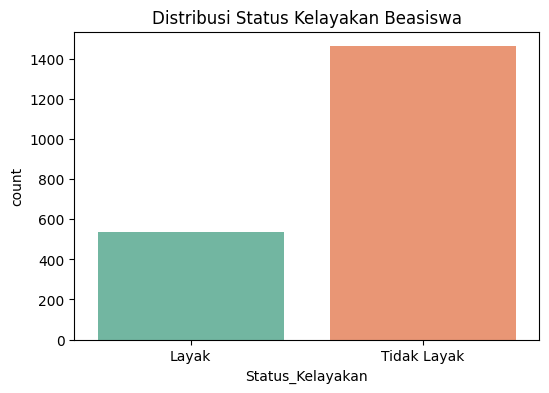

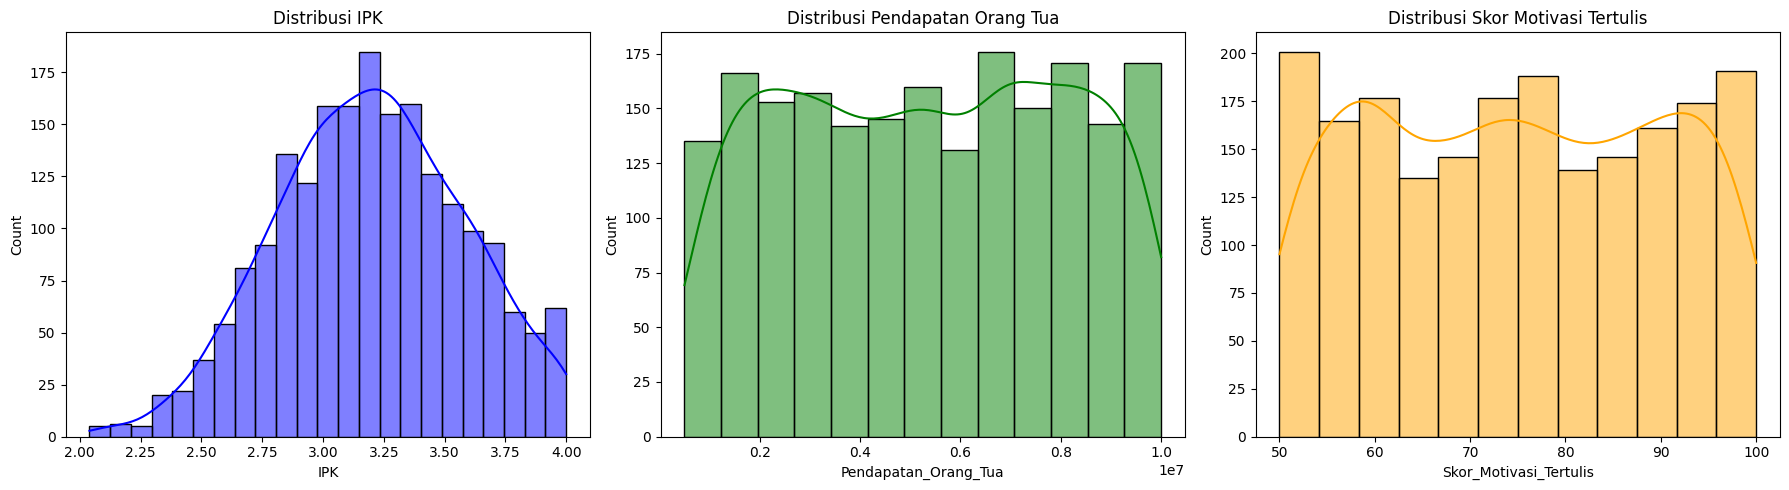

/tmp/ipykernel_808/557966604.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status_Kelayakan', y='IPK', palette='Set2', ax=axes[0])
/tmp/ipykernel_808/557966604.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status_Kelayakan', y='Pendapatan_Orang_Tua', palette='Set2', ax=axes[1])


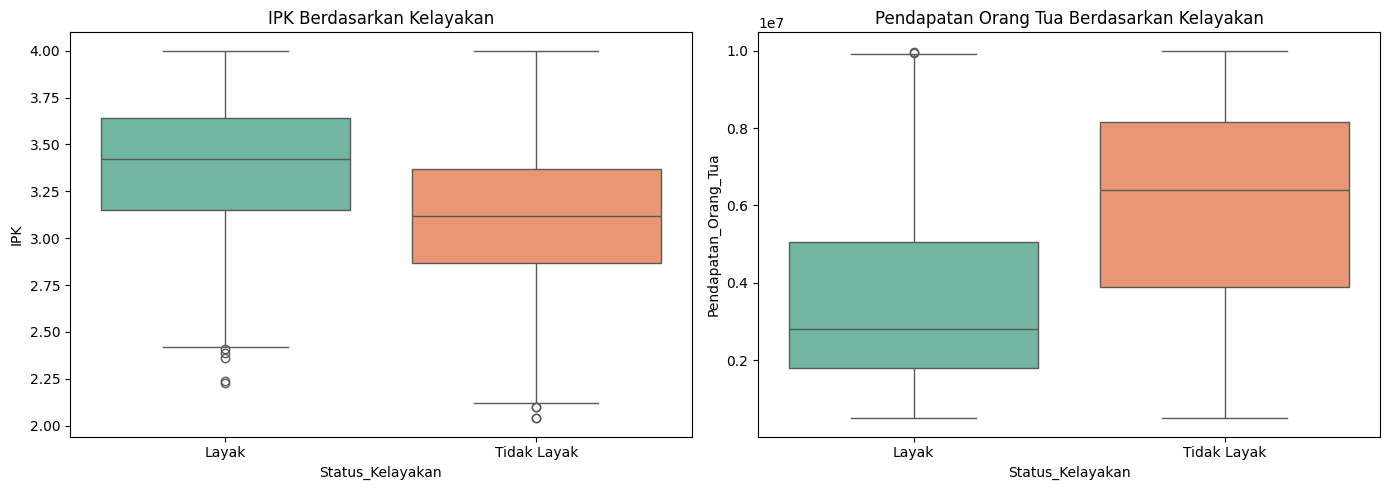

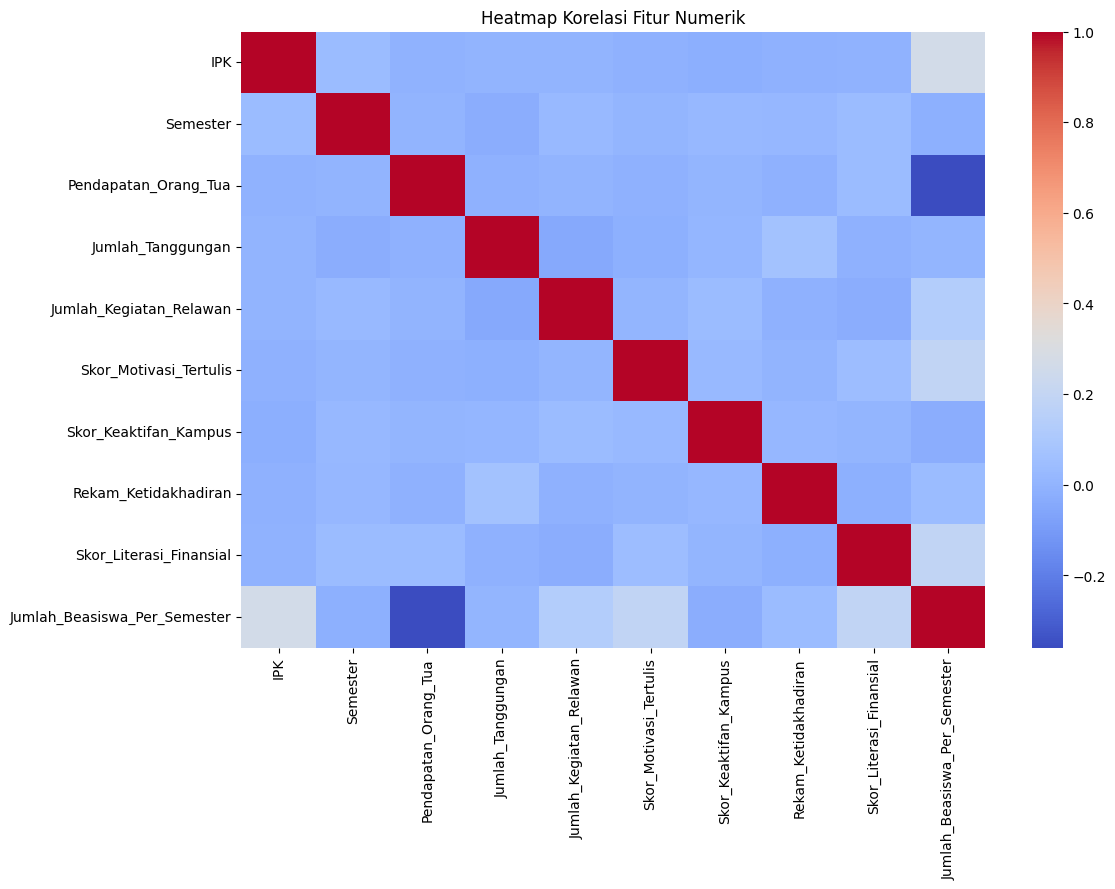

In [3]:
#Type your code here
print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Pengecekan Missing Values ===")
print(df.isnull().sum())

print("\n=== Pengecekan Data Duplikat ===")
print("Jumlah data duplikat:", df.duplicated().sum())

# Visualisasi Distribusi Target (Status Kelayakan)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Status_Kelayakan', palette='Set2')
plt.title('Distribusi Status Kelayakan Beasiswa')
plt.show()

# Visualisasi Distribusi Fitur Numerik Penting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['IPK'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi IPK')

sns.histplot(df['Pendapatan_Orang_Tua'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribusi Pendapatan Orang Tua')

sns.histplot(df['Skor_Motivasi_Tertulis'], kde=True, ax=axes[2], color='orange')
axes[2].set_title('Distribusi Skor Motivasi Tertulis')
plt.tight_layout()
plt.show()

# Hubungan antara IPK, Pendapatan Orang Tua, dan Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Status_Kelayakan', y='IPK', palette='Set2', ax=axes[0])
axes[0].set_title('IPK Berdasarkan Kelayakan')

sns.boxplot(data=df, x='Status_Kelayakan', y='Pendapatan_Orang_Tua', palette='Set2', ax=axes[1])
axes[1].set_title('Pendapatan Orang Tua Berdasarkan Kelayakan')
plt.tight_layout()
plt.show()

# Heatmap Korelasi untuk Fitur Numerik
plt.figure(figsize=(12, 8))

numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
top_features = [
    'Pendapatan_Orang_Tua', 'IPK', 'Skor_Motivasi_Tertulis',
    'Skor_Literasi_Finansial', 'Surat_Rekomendasi', 'Aktif_Organisasi',
    'Jumlah_Kegiatan_Relawan', 'Skor_Keaktifan_Kampus', 'Rekam_Ketidakhadiran',
    'Semester', 'Status_Kelayakan'
]

df_selected = df[top_features]
def terapkan_logika_bisnis(df_input):
    df = df_input.copy()

    # binning pendapatan orang tua
    batas_pendapatan = [0, 5000000, np.inf]
    label_pendapatan = ['Rentan', 'Stabil']
    df['Kategori_Ekonomi'] = pd.cut(df['Pendapatan_Orang_Tua'], bins=batas_pendapatan, labels=label_pendapatan)

    # perhitungan skor performa dinamis
    skor_ipk = (df['IPK'] / 4.0) * 100
    skor_keaktifan = df['Skor_Keaktifan_Kampus']
    skor_relawan = df['Jumlah_Kegiatan_Relawan'] * 10
    df['Skor_Performa_Dinamis'] = (skor_ipk * 0.60) + (skor_keaktifan * 0.20) + (skor_relawan * 0.20)

    # menghapus kolom yang tidak dibutuhkan model
    df = df.drop(columns=['Pendapatan_Orang_Tua'])

    return df
df_selected = terapkan_logika_bisnis(df_selected)
# encoding target (Layak = 1, Tidak Layak = 0)
df_selected['Status_Kelayakan'] = df_selected['Status_Kelayakan'].map({'Layak': 1, 'Tidak Layak': 0})

# memisahkan fitur (X) dan target (y)
X = df_selected.drop(columns=['Status_Kelayakan'])
y = df_selected['Status_Kelayakan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Sedang melatih model Random Forest
=== HASIL EVALUASI ===
              precision    recall  f1-score   support

 Tidak Layak       0.96      0.84      0.90       292
       Layak       0.68      0.91      0.78       108

    accuracy                           0.86       400
   macro avg       0.82      0.87      0.84       400
weighted avg       0.89      0.86      0.87       400



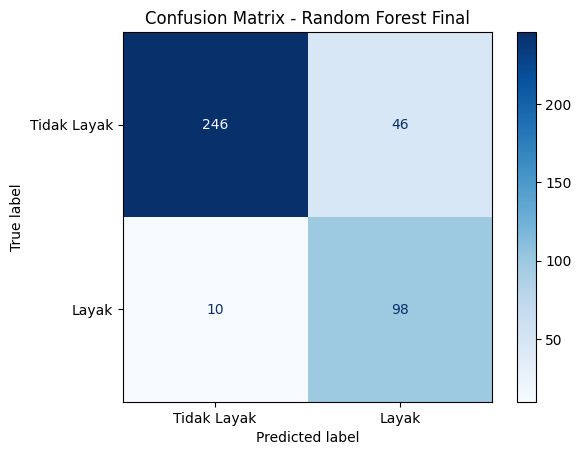

In [5]:
# menentukan kolom numerik dan kategorikal dari 10 fitur teratas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

final_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        min_samples_split=20,
        min_samples_leaf=10,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

# melatih Model
print("Sedang melatih model Random Forest")
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("=== HASIL EVALUASI ===")
print(classification_report(y_test, y_pred, target_names=['Tidak Layak', 'Layak']))

# menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Layak', 'Layak'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest Final')
plt.show()

In [6]:
model_filename = 'eksperimen.pkl'
joblib.dump(final_model, model_filename)
print(f"Model berhasil disimpan dengan nama: {model_filename}")

Model berhasil disimpan dengan nama: eksperimen.pkl


In [7]:
# Load Model
loaded_model = joblib.load('eksperimen.pkl')

# Simulasi Data Input dari Formulir Web (Bentuknya Dictionary / JSON)
data_dari_web = {
    'Pendapatan_Orang_Tua': [4500000],
    'IPK': [3.0],
    'Skor_Motivasi_Tertulis': [85],
    'Skor_Literasi_Finansial': [70],
    'Surat_Rekomendasi': ['Ada'],
    'Aktif_Organisasi': ['Ya'],
    'Jumlah_Kegiatan_Relawan': [0],
    'Skor_Keaktifan_Kampus': [80],
    'Rekam_Ketidakhadiran': [20],
    'Semester': [4]
}

# Konversi Data Web menjadi Pandas DataFrame
df_input = pd.DataFrame(data_dari_web)
df_input = terapkan_logika_bisnis(df_input)

# Prediksi kelas (0 atau 1)
prediksi_kelas = loaded_model.predict(df_input)[0]

# Skor kredibilitas
skor_kredibilitas = loaded_model.predict_proba(df_input)[0][1] * 100

if skor_kredibilitas >= 70:
    keputusan = "LAYAK DIPERPANJANG"
    catatan = "Sistem merekomendasikan perpanjangan otomatis."
elif 50 <= skor_kredibilitas < 70:
    keputusan = "PERLU EVALUASI"
    catatan = "Skor berada di ambang batas. Disarankan penjadwalan konseling/evaluasi dengan prodi."
else:
    keputusan = "TIDAK LAYAK"
    catatan = "Rekam jejak tidak memenuhi standar minimal beasiswa."

print("=== HASIL EVALUASI KALIBER ===")
print(f"Status           : {keputusan}")
print(f"Skor Kredibilitas: {skor_kredibilitas:.1f}%")
print(f"Detail           : {catatan}")

=== HASIL EVALUASI KALIBER ===
Status           : PERLU EVALUASI
Skor Kredibilitas: 62.6%
Detail           : Skor berada di ambang batas. Disarankan penjadwalan konseling/evaluasi dengan prodi.


In [8]:
!pip freeze > requirements.txt
print("File requirements.txt berhasil dibuat.")

File requirements.txt berhasil dibuat.
